# **INCAE PhD Summer Academy**


## *August 2023*
Carlos Siri    

csiri@unc.edu

## Session 1
## Natural Language Understanding


*August 24th, 2023*  
Version 1


# IMPORTANT
***YOU MUST load this notebook to Google's Colab Environment***  
(or have a local computer with a GPU environment installed - which can be a bit tricky)
- Use GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select GPU from drop-down in pop-up
- This will dramatically increase the encoding of text with advanced models such as BERT
- You have limited free GPU hours!
- Make sure you change it back when we are done to "none" and terminate the session!

# **Part 1** Labeled Sentences

In [ ]:
%pip install -U accelerate
%pip install -U transformers

In [ ]:
# 1. We first need to install pickle5 on CoLab
%pip install pickle5

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 132.1/132.1 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pickle5: filename=pickle5-0.0.11-cp310-cp310-linux_x86_64.whl size=255323 sha256=8654b480c3bfb77e5c3b0b23b5d0c4a1fbc216dfe9a12837bce306b38ffbab2f
  Stored in directory: /root/.cache/pip/wheels/7d/14/ef/4aab19d27fa8e58772be5c71c16add0426acf9e1f64353235c
Successfully built pickle5


In [ ]:
# 2. Load other required models
import pickle5 as pickle
import numpy as np
import pandas as pd
import random

In [ ]:
# 3. Connect your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 4. Change your google drive folder
%cd /content/drive/MyDrive/INCAE LLM Seminar

# 5. See what is in the folder: Special shell command to view the files in the current directory of the notebook environment
!ls

Mounted at /content/drive
/content/drive/MyDrive/INCAE LLM Seminar
' '				  NewSentencse_Classified_Sentiment.csv
 data/raw/DEIBalanced.pkl		  pictures
 data/raw/DEILabels.pkl			  Presentation.pptx
 data/raw/DEISampleBalanced.pkl		  SentimentLabels.pkl
 data/raw/equity_tweets.xlsx		  SentimentSampleBalanced.pkl
 artifacts/local_models/model_1			 'Session 1.ipynb'
 model_2			 'Session 2.ipynb'
 data/sample/NewSentence_Classified_DEI.csv


In [ ]:
# import data/raw/equity_tweets.xlsx

df = pd.read_excel("data/raw/equity_tweets.xlsx")

In [ ]:
df

,id,sentence,Neg,Pos,Neutral,DEI,Private Equity
0,1,"""The progress in equity across all sectors is uplifting and brings hope for a fair future!""",0.0,1.0,0.0,1,0
1,2,"""I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness.""",0.0,1.0,0.0,1,0
2,3,"""Equity in education means a brighter future for our children. The change we see is promising!""",0.0,1.0,0.0,1,0
3,4,"""Equity in healthcare is something to be proud of. More people now have the care they need!""",0.0,1.0,0.0,1,0
4,5,"""The push for gender equity in our community is inspiring. We're moving in the right direction!""",0.0,1.0,0.0,1,0
...,...,...,...,...,...,...,...
1475,1476,"""Equity in digital accessibility is a growing field of interest, especially in web design and development.""",0.0,0.0,1.0,1,0
1476,1477,"""The intersection of equity and ethics in business practices is explored in various academic disciplines.""",0.0,0.0,1.0,1,0
1477,1478,"""Equity in leisure and recreation considers factors such as access, affordability, and inclusivity.""",0.0,0.0,1.0,1,0
1478,1479,"""There are different schools of thought on how equity should be pursued in environmental conservation.""",0.0,0.0,1.0,1,0


In [ ]:
df['count'] = 1
sentdf=df
pd.set_option('max_colwidth', 400) # make sure we can see all the sentences
sentdf.tail()

,id,sentence,Neg,Pos,Neutral,DEI,Private Equity,count
1475,1476,"""Equity in digital accessibility is a growing field of interest, especially in web design and development.""",0.0,0.0,1.0,1,0,1
1476,1477,"""The intersection of equity and ethics in business practices is explored in various academic disciplines.""",0.0,0.0,1.0,1,0,1
1477,1478,"""Equity in leisure and recreation considers factors such as access, affordability, and inclusivity.""",0.0,0.0,1.0,1,0,1
1478,1479,"""There are different schools of thought on how equity should be pursued in environmental conservation.""",0.0,0.0,1.0,1,0,1
1479,1480,"""Equity in the distribution of vaccines is an important consideration in global health strategies.""",0.0,0.0,1.0,1,0,1


## 1.2 Mark DEI related Sentences

In [ ]:
# 1. Extract only DEI
DEI=sentdf[['sentence','count','DEI']].copy()


# 4, Rename Column for Label
DEI.rename(columns={ DEI.columns[2]: "label" }, inplace = True)
DEI.rename(columns={ DEI.columns[1]: "raters" }, inplace = True)

# 5. Check Sample Distribution
print(DEI.label.value_counts())
DEI

# 6. Save to file
DEI.to_pickle("data/raw/DEILabels.pkl")

1    1179
0     301
Name: label, dtype: int64


## 1.3 Construct a Sample to build a Classifier on
- We want a classifier that can tell whether a sentence is about a given topic or not (e.g., DEI, Private Equity).
- We will eventually fine-tune a Transformer Model (DistillBERT) in Part 2 of this notebook for our classification task.

In [ ]:
# 1. Load the Business trip data
FILE_TO_LOAD = "data/raw/DEILabels.pkl"
with open(FILE_TO_LOAD, "rb") as f:
  df = pickle.load(f)

In [ ]:
# 2. Explore the dataframe head
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
df.head(5)

,sentence,raters,label
0,"""The progress in equity across all sectors is uplifting and brings hope for a fair future!""",1,1
1,"""I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness.""",1,1
2,"""Equity in education means a brighter future for our children. The change we see is promising!""",1,1
3,"""Equity in healthcare is something to be proud of. More people now have the care they need!""",1,1
4,"""The push for gender equity in our community is inspiring. We're moving in the right direction!""",1,1


In [ ]:
# 4. Let's remove the duplicate sentences (only keep one instance)
print(len(df))
df = df.drop_duplicates(subset='sentence', keep='first')
print(len(df))

1480
1480


In [ ]:
# 5. Get the label counts
df['label'].value_counts()

1    1179
0     301
Name: label, dtype: int64

## 1.4 Ensure a Balanced Sample
- We have 2 labels or "classes" in our data: 0 (negative) and 1 (positive).
- We would like to get a balanced sample so that our classifer needs to learn how to clearly differentiate between positive and negative samples.

***Idea***: Randomly sample an equal number of sentences from the majority class as there are sentences in the minority class .

In [ ]:
# 1. First let's seperate the sentences into different classes.
pos_sentences = df[df['label'] == 1]['sentence'].tolist()
neg_sentences = df[df['label'] == 0]['sentence'].tolist()

In [ ]:
# 2. Check the size of sentences for each class
pos_len = len(pos_sentences)
neg_len = len(neg_sentences)
(pos_len, neg_len)

(1179, 301)

In [ ]:
# 3. Now we form the list of sentences belonging to class 0
sentences = neg_sentences

# 4. There are more sentences belonging to class 1.
# We will randomly sample equal number of sentences from class 1.
# Sentences will be our feature variable (the one predictions are based on)
sentences += random.sample(pos_sentences, neg_len)

# 5. Prepare the labels for classification
# Labels will be our response variable (what we are trying to predict)
labels = [0] * neg_len + [1] * neg_len

In [ ]:
# 6. Let's double check that we have the same number of sentencs and labels
len(sentences), len(labels)

(602, 602)

In [ ]:
# 7. Let's inspect the first couple of sentences (should be positive samples) and last couple of sentences (should be negative samples)
print(f'Negative Samples: \n')
print(*sentences[0:5],sep='\n')
print(f'\nPositive Samples: \n')
print(*sentences[-6:-1],sep='\n')

Negative Samples: 

Just started my journey into equity investment. Excited to see where this leads!
Equity markets are volatile today. Keep an eye on your investments!
Investing in equity can lead to significant gains, but be aware of the risks.
The latest equity funds are performing well. Time to analyze and invest wisely.
Equity is the backbone of modern investment. Never underestimate its power.

Positive Samples: 

"Our school's equity initiative is still new, and its effects are yet to be determined."
"The concept of equity varies across cultures and can be interpreted differently."
"I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness."
"Equity efforts must be sustainable to have a lasting impact."
"A working group on equity in government services has been formed."


In [ ]:
df

,sentence,raters,label
0,"""The progress in equity across all sectors is uplifting and brings hope for a fair future!""",1,1
1,"""I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness.""",1,1
2,"""Equity in education means a brighter future for our children. The change we see is promising!""",1,1
3,"""Equity in healthcare is something to be proud of. More people now have the care they need!""",1,1
4,"""The push for gender equity in our community is inspiring. We're moving in the right direction!""",1,1
...,...,...,...
1475,"""Equity in digital accessibility is a growing field of interest, especially in web design and development.""",1,1
1476,"""The intersection of equity and ethics in business practices is explored in various academic disciplines.""",1,1
1477,"""Equity in leisure and recreation considers factors such as access, affordability, and inclusivity.""",1,1
1478,"""There are different schools of thought on how equity should be pursued in environmental conservation.""",1,1


In [ ]:
# 8. Save Balanced Business Sample
df=pd.DataFrame(
    {'sentences': sentences,
     'labels': labels})
df.to_pickle('data/raw/DEISampleBalanced.pkl')

# **Part 2**: Fine-tune a pre-trained Transformer Model

To work with DistilBERT we need two great packages:

**huggingface Transformers**
*State-of-the-art Natural Language Processing for TensorFlow and PyTorch*
https://transformer.huggingface.co/

**PyTorch**
*An open source machine learning framework that accelerates the path from research prototyping to production deployment*
https://pytorch.org/

![Transformers](https://venturebeat.com/wp-content/uploads/2019/09/hugging-face.png?fit=750%2C375&strip=all "Transformers")




In [ ]:
# 1. We will need to install huggingface transformers first
%pip install transformers

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 7.5/7.5 MB 26.6 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 268.8/268.8 kB 30.6 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 7.8/7.8 MB 72.3 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1.3/1.3 MB 78.4 MB/s eta 0:00:00


In [ ]:
# 2. Load other required models
from tqdm import tqdm
import pickle5 as pickle
import numpy as np
import pandas as pd
import torch
import transformers as ppb
import warnings
warnings.filterwarnings('ignore')

## 2.1 Load Pre-Trained DistilBERT
- We will use ``distilbert-base-cased`` model for fine-tuning because it runs faster than BERT (which is important given the time we have in the classroom).
- There are other pre-trained models like ``xlnet``, ``BERT``, ``deberta``, ``BERTweet``,  etc.
- The full list of models can be found at https://huggingface.co/models
- To use other models, just change the variable ``model_name``

In [ ]:
# 1a. For DistilBERT:
model_name = 'distilbert-base-cased'

# 1b. For BERT:
#model_name = 'bert-base-cased'

# 2. Import tokenizer and model imports from huggingface
from transformers import AutoTokenizer, AutoModel

# 3. Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

## 2.2 Load Balanced Sample and Split data for Training and Testing
- Load our previously saved Balanced Sample (sentences with 50% positive and 50% negatve labels)
- We will use ``train_test_split`` from sklearn to split the data for training and testing.
  - 80% of the data is used for training and 20% for testing
  - We stratify the sample by label: Why?
  - We will seed the random state to 42: What is the effect of doing so?

In [ ]:
# 1. Load the data (if you named the file differently, be sure to change the filename below!)
df=pd.read_pickle("data/raw/DEISampleBalanced.pkl")
df.head()

,sentences,labels
0,Just started my journey into equity investment...,0
1,Equity markets are volatile today. Keep an eye...,0
2,Investing in equity can lead to significant ga...,0
3,The latest equity funds are performing well. T...,0
4,Equity is the backbone of modern investment. N...,0


In [ ]:
# 2. Extract Sentences (Xs) and Labels (ys)
sentences=df.sentences.to_list()
labels=df.labels.to_list()

In [ ]:
# 3. Load train_test_split from sklearn and split the Sample into training and testing data
from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(sentences,labels,test_size=0.2, stratify=labels, random_state=42)
print(f'Training Sample contains {len(train_sentences)} sentences\nTesting Sample contains {len(test_sentences)} sentences.')

Training Sample contains 481 sentences
Testing Sample contains 121 sentences.


## 2.3 Convert data for fine-tuning DistilBERT.
We apply the following:
- Tokenization
- Padding
- Masking

Fortunately, there is a function called ``encode_plus`` that does all 3 tasks for us.  

In [ ]:
# 1. Set the maximum length value
padding_type = 'max_length'

# 2. Restrict to maximum length 75 to save RAM memory
# Note: Use the same 'max_length' in training and testing.
# You can change this length depending on GPU RAM.
# If you are using greater lengths, use lower batch sizes (eg: 8, 16)
# Change the variable per_device_train_batch_size in 1.11 Training Arguments function.
max_length = 75

In [ ]:
# 3. Function to tokenize the sentences and return tokens and padding
def tokenize_sentences(sent):
  input_ids = []
  attention_mask = []
  token_ids = []

  for i in tqdm(range(len(sent))):
    sentence = sent[i]
    encoded = tokenizer.encode_plus(text=sentence,
                                    add_special_tokens=True,
                                    padding=padding_type,
                                    max_length=max_length,
                                    truncation=True,
                                    return_token_type_ids=True,
                                    return_tensors='pt')

    input_ids.append(encoded['input_ids'])
    attention_mask.append(encoded['attention_mask'])

  input_ids = torch.cat(input_ids, dim=0, out=None)
  attention_mask = torch.cat(attention_mask, dim=0, out=None)

  return input_ids, attention_mask

In [ ]:
# 4. Convert training data
train_input_ids, train_attention_mask = tokenize_sentences(train_sentences)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 481/481 [00:00<00:00, 3809.88it/s]


In [ ]:
# 5. Convert test data
test_input_ids, test_attention_mask = tokenize_sentences(test_sentences)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 121/121 [00:00<00:00, 5076.88it/s]


## 2.4 Turn Lables into a Tensor
- A ``Tensor`` is similar to a numpy array.
- However, with numpy arrays computation on GPUs is not straightforward.
- You may need specialized data arrays to convert numpy array into GPU executable form.
- ``Tensor`` makes this job easier with smooth data migration among ``cpu``, ``gpu`` and ``local memory``.
- ``LongTensor`` is similar to ``int`` in programming languages. It handles integer tensors.

In [ ]:
# 1. Convert labels to tensor (PyTorch's array) for training
train_labels = torch.LongTensor(train_labels)
test_labels = torch.LongTensor(test_labels)

In [ ]:
# 2. Let's see the shape of our inputs
print("Tokenized inputs shape: {} ".format((train_input_ids.size()[0], train_input_ids.size()[1])))
print("Attention mask shape: {} ".format((train_attention_mask.shape[0], train_attention_mask.shape[1])))

Tokenized inputs shape: (481, 75) 
Attention mask shape: (481, 75) 


## 2.5 Create a Data Loader

When training on GPUs, retreiving batches of data swiftly is important for less overhead and more parallel computation.



In [ ]:
# 1. Class to retrieve batches efficiently for GPU computation

class TaskDataset(torch.utils.data.Dataset):
  def __init__(self, inputids, attnmasks, labels):
    self.inputids = inputids
    self.attnmasks = attnmasks
    self.labels = labels

  def __getitem__(self, idx):
    item = {}
    item['input_ids'] = self.inputids[idx]
    item['attention_mask'] = self.attnmasks[idx]
    item['labels'] = self.labels[idx]
    return item

  def __len__(self):
    return len(self.labels)

In [ ]:
# 2. Convert training data into data loader object
train_loader = TaskDataset(train_input_ids, train_attention_mask, train_labels)

# 3. Convert test data into data loader object
test_loader = TaskDataset(test_input_ids, test_attention_mask, test_labels)

## 2.6 Model Evaluation Metrics
- We will evaluate model performance with accuracy and f1 score
- We also want to examine recall and precision

In [ ]:
# 0. Import libraries
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from scipy.special import softmax

# 1. Function to compute precision, recall, f1 and accuracy
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    pred_scores = softmax(pred.predictions, 1)
    pred_scores = np.max(pred_scores, 1)
    if(numclasses > 2):
        avg = 'macro'
    else:
        avg = 'binary'
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=avg)
    acc = accuracy_score(labels, preds) * 100
    return {
        'accuracy': acc,
        'f1': f1 * 100,
        'precision': precision,
        'recall': recall,
        'pred_scores': pred_scores,
        'pred_indices': preds
    }

## 2.7 Initiantiate Classification Model

- Our model has a DistilBERT layer followed by classification layer
- In the final classification layer we get 2 outputs for each of the classes

In [ ]:
# 1. Import methods from hugging face
from transformers import AutoModelForSequenceClassification

# 2. Let's first define the number of classes in our dataset: in binary classification we have 2 classes (0 and 1)
numclasses = 2

# 3. Instantiate the model
model = AutoModelForSequenceClassification.from_pretrained(
		model_name,
		output_hidden_states=False,
		output_attentions=False,
		num_labels=numclasses
		)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 2.8 Set Training parameters
- Before training, we need to define couple of things.
- We will mention all the hyper-parameters of our model using ``Trainer``. This helps us avoid loops and iterating over batches.



In [ ]:
# 1. Hyper-parameters for our model
numepochs = 5

# 2. Mention large number to avoid saving models (They are huge!)
logging_steps = 10000000
save_steps = 1000000

In [ ]:
# 3. Import TrainingArguments from huggingface
from transformers import TrainingArguments

# 4. per_device_train_batch_size is the batch size we use during training.
# If you are facing RAM issues in the colab, change this value to 8 or 16.
training_args = TrainingArguments(
		output_dir=' ',
		num_train_epochs=numepochs,
		warmup_steps=1000,
		weight_decay=0.01,
    per_device_train_batch_size=32, # Change this value if you have RAM issue in colab
		logging_dir=' ',
		logging_steps=logging_steps,
		save_steps=save_steps
		)

## 2.9 And Now Fine-Tuning!
We have all the ingredients to fine-tune the pre-trained (DistilBERT) model to our classification task.
- Fine-tuing a transfomer for a classifcation task takes a lot longer than fitting a logistic regression to feature vectors (e.g., DistilBERT vectors from text as we did in Class 24)
- We hope for much better accuracy to make it work the computational expense!

In [ ]:
%%time
# 1. Import trainer from huggingface
from transformers import Trainer

# 2. Load the trainer class from huggingface
trainer = Trainer(
		model=model,
		args=training_args,
		train_dataset=train_loader,
		eval_dataset=test_loader,
		compute_metrics=compute_metrics
		)

# 3. Fine-Tune the Model
trainer.train()

Step,Training Loss


CPU times: user 7.74 s, sys: 905 ms, total: 8.65 s
Wall time: 10.2 s


TrainOutput(global_step=80, training_loss=0.6311821937561035, metrics={'train_runtime': 5.9469, 'train_samples_per_second': 404.414, 'train_steps_per_second': 13.452, 'total_flos': 46667591860500.0, 'train_loss': 0.6311821937561035, 'epoch': 5.0})

## 2.10 Save Fine-Tuned Model
- To save the model, we use ``output_dir`` variable.   
- Feel free to change this variable.   
- But remember this path to re-load the model again.
- You can also share your model with others (but you should give them the code to run it as well!).

In [ ]:
# 1. Path to save the model
# If you want to use another directory, change here.
# Note. The folder should exist before saving.
# Eg: output_dir = 'drive/MyDrive/Business_model/'
output_dir = 'artifacts/local_models/model_1/'

# 2. Save the model to output_dir
trainer.save_model(output_dir)

## 2.11 Evaluate Fine-Tuned Model on the Test Data
We fine-tuned DistilBERT to classify hote review sentences. Let's see how well our fine-tuned model does!

In [ ]:
# 1. Evaluates the model on test data
testscores = trainer.evaluate()

Trainer is attempting to log a value of "[0.6633918  0.6967126  0.7229453  0.7090352  0.65891504 0.67222506
 0.69869214 0.70702624 0.7306689  0.6949046  0.6936786  0.71104074
 0.72241414 0.6998039  0.68679225 0.70348763 0.7385927  0.7322312
 0.70087224 0.6951048  0.68353707 0.7139855  0.73081356 0.6951828
 0.7090021  0.6949741  0.72751135 0.6805561  0.72803885 0.7297523
 0.69910353 0.7205359  0.6572096  0.7334035  0.7003739  0.71976
 0.69412106 0.69188875 0.73136926 0.691419   0.67866313 0.6983503
 0.7149486  0.7200927  0.66449684 0.7015057  0.51660424 0.6693359
 0.6833542  0.7106275  0.7087537  0.69864434 0.6959207  0.71618634
 0.7119906  0.7313084  0.7348545  0.71533173 0.725093   0.69569993
 0.70519626 0.7165843  0.6977117  0.72296053 0.73744994 0.71717584
 0.5789507  0.731966   0.68918085 0.7043396  0.67589915 0.69173175
 0.58543026 0.67253864 0.7429978  0.6711956  0.72330654 0.58239615
 0.7122142  0.73288745 0.68225014 0.6830814  0.71024626 0.6806506
 0.71796274 0.70449936 0.69335

In [ ]:
# 1. Print accuracy score and f1 score
print("Test Accuracy {} ".format(testscores['eval_accuracy']))
print("Test F1 Score {} ".format(testscores['eval_f1']))

Test Accuracy 100.0 
Test F1 Score 100.0 


## 2.12 Check the Classifcation Report

In [ ]:
# 1. Get the predictions from trainer
test_pred_labels = testscores['eval_pred_indices']
test_pred_scores = testscores['eval_pred_scores']

In [ ]:
# 2. Import required package
from sklearn.metrics import classification_report

# 3. Output Classifcation Report
print(classification_report(test_labels, test_pred_labels))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        60

    accuracy                           1.00       121
   macro avg       1.00      1.00      1.00       121
weighted avg       1.00      1.00      1.00       121



## 2.13 Check the Confusion Matrix

Text(0.5, 23.52222222222222, 'Predicted')

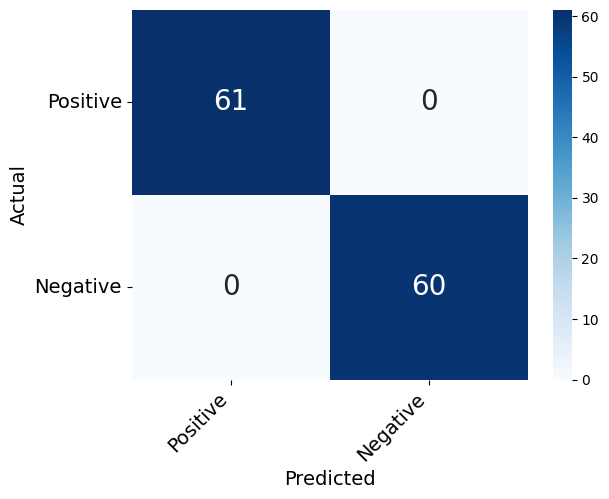

In [ ]:
# 1. Load required packages
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

# 2. Plot the confusion matrix
con_matrix = confusion_matrix(test_labels, test_pred_labels)
confusion_matrix_df = pd.DataFrame(con_matrix, ('Positive', 'Negative'), ('Positive', 'Negative'))

# 3. Visualize
heatmap = sns.heatmap(confusion_matrix_df, annot=True, annot_kws={"size": 20}, fmt="d", cmap="Blues")
bottom, top = heatmap.get_ylim()
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize = 14)
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize = 14)
plt.ylabel('Actual', fontsize = 14)
plt.xlabel('Predicted', fontsize = 14)

In [ ]:
## Create a dataframe to store sentences and labels for each topic.
df = pd.DataFrame({'sentences': test_sentences,
                   'predicted_labels': test_pred_labels,
                   'test_labels': test_labels,
                   'predicted_scores': test_pred_scores,
                   })

# Let's look at our dataframe.
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
df

,sentences,predicted_labels,test_labels,predicted_scores
0,How does equity investment impact job creation and economic development? A broader perspective! #economy,0,0,0.663392
1,Biotechnology equity is pushing the boundaries of innovation. Stay on the cutting edge! #biotech #investment,0,0,0.696713
2,"""Our government's equity policy is poorly implemented and misses the mark. It's not effective.""",1,1,0.722945
3,"""Workplace equity may involve practices that ensure fairness in hiring, compensation, and career development.""",1,1,0.709035
4,Exploring equity investment in agribusiness? It's a field with growth and societal impact. #agriculture,0,0,0.658915
...,...,...,...,...
116,Equity investing in healthcare is more than profits; it's about enhancing lives. Consider the impact! #healthcare,0,0,0.680079
117,"""Our children deserve equity in schools! The time to act is now, not tomorrow, not later!""",1,1,0.702286
118,"""Why is equity in housing still an issue? It's time to make a home for everyone!""",1,1,0.679631
119,"""Understanding equity is a continuous process that requires openness to new insights and perspectives.""",1,1,0.731284


## 2.14 Check where our Classifier failed

In [ ]:
# 1. Let's see where our classifier was wrong.
df[df.predicted_labels!=df.test_labels]

,sentences,predicted_labels,test_labels,predicted_scores


In [ ]:
# 2. Let's see where our classifier was most uncertain
df[df.predicted_scores<.7]

,sentences,predicted_labels,test_labels,predicted_scores
0,How does equity investment impact job creation and economic development? A broader perspective! #economy,0,0,0.663392
1,Biotechnology equity is pushing the boundaries of innovation. Stay on the cutting edge! #biotech #investment,0,0,0.696713
4,Exploring equity investment in agribusiness? It's a field with growth and societal impact. #agriculture,0,0,0.658915
5,Just attended an international equity conference. Global perspectives enrich understanding! #conference #investing,0,0,0.672225
6,Innovations in equity market analysis tools are enhancing investment strategies. Stay updated! #finance,0,0,0.698692
9,5G technology is shaping equity markets in unexpected ways. Stay tuned for exciting developments! #5G #investing,0,0,0.694905
10,"Equity crowdfunding is democratizing investment. Small investors, big dreams! #finance #crowdfunding",0,0,0.693679
13,Dividend equity investments can provide steady income. Have you considered them? #finance #income,0,0,0.699804
14,ESG and equity investments are aligning more than ever. A socially responsible choice! #sustainability,0,0,0.686792
19,Equity research firms provide invaluable insights. Leverage them for better investment decisions! #finance,0,0,0.695105


#### **Discussion Point**
What might be a bigger problem?
1. Misclassifed sentences with high certaininty (i.e., high predicted scores)
2. Correctly classified sentences with low certainty (i.e., low predicted scores)

What can you do to mitigate the problem(s)?

## 2.15 Improveing Classification Performance

We can still improve the performance of our Classifier!
Change these hyper-paramaters:
- max_length
- num_epochs

## ***DO NOT FORGET TO TERMINATE YOUR GPU SESSION***  
- Remove GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select NONE from drop-down in pop-up
- You have limited free GPU hours!
- Make sure you change it back when we are done to "None" and terminate the session!

# **Part 3** Classify New Sentences with our Fine-Tuned Transformer Model
- A fine-tuned model is only useful when we can use it to rapidly classify many, many new sentences.

1. Load the saved fine-tuned model
2. Use it to classify new sentences

# IMPORTANT
***YOU MUST load this notebook to Google's Colab Environment***  
(or have a local computer with a GPU environment installed - which can be a bit tricky)
- Use GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select GPU from drop-down in pop-up
- This will dramatically increase the encoding of text with advanced models such as BERT
- You have limited free GPU hours!
- Make sure you change it back when we are done to "none" and terminate the session!

## 3.1 Prerequisites

In [ ]:
# 1. We will need to install huggingface transformers first
%pip install transformers

In [ ]:
# 2. Install pickle5 on CoLab
%pip install pickle5

In [ ]:
# 3. Load other required models
from tqdm import tqdm
import pickle5 as pickle
import numpy as np
import pandas as pd
import torch
import transformers as ppb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 4. Connect your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 5. Navigate to the folder where the files for Class 26 are:
%cd /content/drive/MyDrive/INCAE LLM Seminar
# 6. See what is in the folder: Special shell command to view the files in the current directory of the notebook environment
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/INCAE LLM Seminar
' '				  NewSentencse_Classified_Sentiment.csv
 data/raw/DEIBalanced.pkl		  pictures
 data/raw/DEILabels.pkl			  Presentation.pptx
 data/raw/DEISampleBalanced.pkl		  SentimentLabels.pkl
 data/raw/equity_tweets.xlsx		  SentimentSampleBalanced.pkl
 artifacts/local_models/model_1			 'Session 1.ipynb'
 model_2			 'Session 2.ipynb'
 data/sample/NewSentence_Classified_DEI.csv


## 3.2 New Sentences
- I defined several sentences in a list of strings
- You are welcome to add your own sentences!

In [ ]:
New_Sentences = [
    'Equity in the workplace ensures fair treatment for all employees.',
    'Private equity investment has the potential for substantial returns.',
    'Promoting gender equity can lead to a more inclusive environment in the company.',
    'The latest equity deal led to a successful buyout of a well-established business.',
    'Inclusion and equity are essential for creating a diverse workforce.',
    'Venture capitalists often look for high growth in private equity investments.',
    'Equity and diversity training can make a meaningful impact on organizational culture.',
    'Leveraging equity in investment can amplify returns on successful ventures.',
    'An equity-first approach ensures that every employee has access to the same opportunities.',
    'Private equity firms often specialize in specific sectors like technology or healthcare.',
    'In the business world, equity principles are fundamental for ethical practices.',
    'Equity investment in emerging markets offers opportunities but comes with risks.',
    'The push for racial equity has led to significant changes in many organizations.',
    'An equity stake in a startup can lead to substantial profits if the company succeeds.',
    'Education equity is vital for ensuring that all students have access to quality learning.',
    'Investing in private equity funds can be a way to diversify an investment portfolio.',
    'Efforts to promote equity in hiring are gaining traction across various industries.',
    'A strategic equity partnership can open new markets and growth opportunities.',
    'Equity considerations must be part of the planning process for any new policy.',
    'A significant equity investment in a new tech company has raised eyebrows in the financial world.',
    'Working towards pay equity is a goal that many modern organizations share.',
    'Equity financing is a common way for businesses to raise capital without accruing debt.',
    'Understanding cultural equity is essential for international business operations.',
    'The equity market has been particularly volatile this quarter, affecting many investments.',
    'Building equity in a home is a priority for many first-time homeowners.',
    'Equity analysis is an essential tool for investors in the stock market.',
    'Corporate social responsibility includes a commitment to community equity.',
    'Equity-based compensation can align the interests of employees and shareholders.',
    'With a focus on health equity, the company provides insurance for underserved populations.',
    "Equity considerations were central in the merger discussions between the two tech giants."
]

## 3.3 Load our Fine-tuned DistilBERT model (or other)

- Here, we will load the fine-tuned and saved model.
- You would have saved model during training using ``output_dir`` variable.
- We will use the same path to load the model again.

In [ ]:
# 1. Change the path where you saved the trained model.
output_dir = 'artifacts/local_models/model_1'

# 2. Import tokenizer and model imports from huggingface
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 3. Note. If you have different model (eg: BERT) during training change the appropriate name here.
model_name = 'distilbert-base-cased'
#model_name = 'bert-base-cased'

# 4. Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 5. Let's first calculate the number of classes in our dataset
numclasses = 2

# 6. Instatiate the model
model = AutoModelForSequenceClassification.from_pretrained(
		output_dir,
		output_hidden_states=False,
		output_attentions=False,
		num_labels=numclasses
		)

## 3.4 Prepare our New Sentences for Classification
- Tokenization
- Padding
- Masking
Again, we can use a function called ``encode_plus`` that does all the 3 tasks for us.

In [ ]:
# 1. Set the maximum length value
padding_type = 'max_length'

# 2. Restrict to maximum length 75 to save RAM memory
# Note: Use the same 'max_length' in training and testing.
max_length = 75

In [ ]:
# 3. Function to tokenize the sentences and return tokens and padding
def tokenize_sentences(sent):
  input_ids = []
  attention_mask = []
  token_ids = []

  for i in tqdm(range(len(sent))):
    sentence = sent[i]
    encoded = tokenizer.encode_plus(text=sentence,
                                    add_special_tokens=True,
                                    padding=padding_type,
                                    max_length=max_length,
                                    truncation=True,
                                    return_token_type_ids=True,
                                    return_tensors='pt')

    input_ids.append(encoded['input_ids'])
    attention_mask.append(encoded['attention_mask'])

  input_ids = torch.cat(input_ids, dim=0, out=None)
  attention_mask = torch.cat(attention_mask, dim=0, out=None)

  return input_ids, attention_mask

In [ ]:
# 4. Prepare New Sentences
test_input_ids, test_attention_mask = tokenize_sentences(New_Sentences)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 30/30 [00:00<00:00, 4130.69it/s]


## 3.5 Convert New Sentence Data into a Data Loader Object

- When training on GPUs, retreiving batches of data swiftly is important for less overhead and more parallel computation.



In [ ]:
# 1. Load utilities from pytorch
from torch.utils.data import TensorDataset, DataLoader

# 2. Convert data in correct formats
test_array = TensorDataset(test_input_ids, test_attention_mask)
test_loader = DataLoader(test_array, batch_size=8)

## 3.6 Initialize Model with Parameters
- We don't train the model here
- We use our fine-tuned model to classify new sentences
- But first, we need to initialize it


In [ ]:
# 1. Import TrainingArguments from huggingface
from transformers import TrainingArguments, Trainer

# 2. Define the training args
training_args = TrainingArguments(
		output_dir=' ',
		logging_dir=' ',
		)

# 3. Load the trainer class from huggingface
# We will set train_dataset and eval_dataset to test_loader
trainer = Trainer(
		model=model,
		args=training_args,
		train_dataset=test_loader,
		eval_dataset=test_loader
		)

## 3.7 Classify New Sentences

In [ ]:
%%time
# 1. Set the model to evalution mode
model.eval()

# 2. Use GPU as primary device for computation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Store the list of predictions
test_pred_labels = []
test_pred_scores = []
with torch.no_grad():
    for input_ids, attn_mask in test_loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        outputs = model(input_ids, attn_mask)
        outputs = outputs['logits']
        test_pred_labels.extend(torch.argmax(outputs, 1).cpu().detach().numpy().tolist())
        test_pred_scores.extend(torch.max(torch.softmax(outputs, 1), 1)[0].cpu().detach().numpy().tolist())

CPU times: user 34.2 ms, sys: 0 ns, total: 34.2 ms
Wall time: 34 ms


In [ ]:
# 4. Create a dataframe to store sentences and predicted labels
df = pd.DataFrame({'sentences': New_Sentences,
                   'predicted_labels': test_pred_labels,
                   'predicted_scores': test_pred_scores
                   })

## 3.8 Check Our Classifier's Predictions!

It's a good idea to check a model's predictions for face-validity.

In [ ]:
# 1. Let's see what our fine-tuned model classified as positive samples
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
display(df[df.predicted_labels==1].sort_values(by=['predicted_scores']))

,sentences,predicted_labels,predicted_scores
18,Equity considerations must be part of the planning process for any new policy.,1,0.504865
8,An equity-first approach ensures that every employee has access to the same opportunities.,1,0.508359
28,"With a focus on health equity, the company provides insurance for underserved populations.",1,0.508423
10,"In the business world, equity principles are fundamental for ethical practices.",1,0.515258
3,The latest equity deal led to a successful buyout of a well-established business.,1,0.515780
19,A significant equity investment in a new tech company has raised eyebrows in the financial world.,1,0.516851
2,Promoting gender equity can lead to a more inclusive environment in the company.,1,0.517379
22,Understanding cultural equity is essential for international business operations.,1,0.521277
0,Equity in the workplace ensures fair treatment for all employees.,1,0.522215
29,Equity considerations were central in the merger discussions between the two tech giants.,1,0.522741


In [ ]:
# 2. Let's see what our fine-tuned model classified as negative samples
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
display(df[df.predicted_labels==0].sort_values(by=['predicted_scores']))

,sentences,predicted_labels,predicted_scores
20,Working towards pay equity is a goal that many modern organizations share.,0,0.500586
24,Building equity in a home is a priority for many first-time homeowners.,0,0.503311
9,Private equity firms often specialize in specific sectors like technology or healthcare.,0,0.506869
21,Equity financing is a common way for businesses to raise capital without accruing debt.,0,0.507502
7,Leveraging equity in investment can amplify returns on successful ventures.,0,0.508621
15,Investing in private equity funds can be a way to diversify an investment portfolio.,0,0.508864
25,Equity analysis is an essential tool for investors in the stock market.,0,0.508898
8,An equity-first approach ensures that every employee has access to the same opportunities.,0,0.509129
1,Private equity investment has the potential for substantial returns.,0,0.509604
11,Equity investment in emerging markets offers opportunities but comes with risks.,0,0.510813


In [ ]:
# Save Sentences and Predictions to a CSV file
FILE_NAME_TO_SAVE = 'data/sample/NewSentence_Classified_DEI.csv' # Change the file name to whatever you like
df.to_csv(FILE_NAME_TO_SAVE, header=True, index=False)

## ***DO NOT FORGET TO TERMINATE YOUR GPU SESSION***  
- Remove GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select NONE from drop-down in pop-up
- You have limited free GPU hours!
- Make sure you change it back when we are done to "None" and terminate the session!

# **Part 4**: *Where to from Here?* **Building a Better Classifier** (is not hard!)

You can improve the performance of a classifer relatively easily using the below strategies:

## How to improve predictive performance 1: **Different Pre-Trained Model**
There are many pre-trained models available at https://huggingface.co/models. Which one works best for your specific purpose (i.e., classifcation of sentences from hotel reviews) depends on many factors (e.g., which data a model was pre-trained on, how big its vocabulary is, how advanced its architecture is, etc.).
1. Try using BERT cased and see what happens
2. Try a different model like RoBERTa
3. If you are working with Tweets, consider BERTweet

## How to improve the model's performance 2: **Label more Sentences**
In many cases you can improve the performance of your classifier by giving it more data to train on. You might pursue two objectives: First, help you classifier more accurately predict sentences that are difficult to predict. Second, add more variation in sentence content and structure to your training sample. You might proceed as follows:
1. Train a classifier
2. Investigate which sentences of your training are misclassified
3. Embed those sentences with the Universal Sentence Encoder (Class 24) or SentenceBERT.
4. Search for similar (embedded) sentences in a large pool of sentence candiates (see Class 24).
5. Label these sentences and add them to your sample.
6. Train-Test-Split, train the classifier (on train) and evaluate (on test).
7. Repeat 2-6 as needed until you are satisfied.


## How to improve the model's performance 3: Try **Active Learning**
In active learning, we build the sample on which we train our classifier up step-by-step instead of all at once.
1. Start with a small, balanced sample of labeled data (maybe 200 sentences)
2. Train a classifier
3. Use the classifier to predict new sentences (maybe 3000)
  - Check for which sentences the classifier is "most uncertain", that is, where the scores or probabilites are lowest. In other words, where the predicitons are closest to the decision boundaries between classes.
4. Label the N most uncertain sentences (e.g., 50), remove them from the pool of unlabeled sentences, and add them to your sample
5. Repeat steps 2-4 (e.g., now with 250 sentences = original + 50) and track how model performance improves.
6. Repeat steps 2-5 until the improvement of your model's performance becomes marginal.

## *To get a truly great classifier, you'd probably need to combine all of the above!*